# Generation Results

Compile the generation results of the experiment "nq_open_with_reference" into a single file for easier analysis.

## Setup & Configuration

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import gc
from pathlib import Path
from tqdm import tqdm
from datetime import datetime

from utils.metrics.calculate_metric import calculate_agg_metric
from utils.set_random_seed import set_random_seed

set_random_seed(42)

INFO 05-09 20:45:13 [__init__.py:216] Automatically detected platform cuda.


In [5]:
GENERATIONS_BASE_PATH="runs"
# EXPERIMENTS = ["qwen", "qwen_default", "llama", "llama_default"]
EXPERIMENTS = ["llama"]
# METRICS = ["rouge_l", "squad_v2_best_exact", "squad_v2_best_f1"] 
METRICS = ["squad_v2_best_exact", "squad_v2_best_f1"] 
GENERATION_PATTERNS = ["rag", "zeroshot", "dmcr"]  
CACHE_ENABLED = True
RESULTS_CACHE_PATH = "generation_results_compiled.feather"

# Visualization config
PASTEL_COLORS = {
    "rag": "#87CEEB",           # Pastel blue
    "zeroshot": "#98D8C8",      # Pastel teal
    "dmcr": "#F7DC6F",          # Pastel yellow
}
# Fallback palette for any unmatched patterns
PASTEL_PALETTE = ["#87CEEB", "#98D8C8", "#F7DC6F", "#F8B88B", "#D7BDE2"]

### Discovery & Available Folders

In [6]:
# Discover available experiment folders and generation files
def discover_available_runs(base_path):
    """List all available experiment runs and their generation files."""
    available = {}
    if not os.path.exists(base_path):
        print(f"Base path '{base_path}' does not exist")
        return available
    
    for exp_folder in os.listdir(base_path):
        exp_path = os.path.join(base_path, exp_folder)
        if os.path.isdir(exp_path):
            gen_path = os.path.join(exp_path, "generations")
            if os.path.exists(gen_path):
                gen_files = [f for f in os.listdir(gen_path) if f.endswith(".json")]
                available[exp_folder] = gen_files
    
    return available

available_runs = discover_available_runs(GENERATIONS_BASE_PATH)
print("Available experiment runs and generation files:")
for exp, files in available_runs.items():
    print(f"  {exp}: {files}")

Available experiment runs and generation files:
  qwen_default: ['zeroshot.json', 'rag.json']
  llama_default: ['rag_extraction.json', 'rag.json', 'zeroshot.json']
  llama: ['rag_extraction.json', 'f1_binary.json', 'em.json', 'rougel_binary.json', 'rag.json', 'zeroshot.json', 'f1.json', 'rougel.json']
  qwen: ['rag.json', 'zeroshot.json', 'rag_extraction.json']


In [7]:
# Helper function to extract generation method from filename
def extract_generation_method(filename):
    """Extract generation method from filename (e.g., 'rag.json' -> 'rag')."""
    return filename.replace(".json", "")

# Helper function to check if generation file matches any pattern
def matches_pattern(filename, patterns):
    """Check if filename matches any of the patterns."""
    for pattern in patterns:
        if pattern in filename:
            return pattern
    return "dmcr"


## Data Loading & Metric Calculation (Only Llama)

In [12]:

available_runs = discover_available_runs(GENERATIONS_BASE_PATH)
print("Available experiment runs and generation files:")
for exp, files in available_runs.items():
    print(f"  {exp}: {files}")

# Load from cache if available
LOAD_FROM_CACHE = CACHE_ENABLED and os.path.exists(RESULTS_CACHE_PATH)

if LOAD_FROM_CACHE:
    print(f"Loading cached results from {RESULTS_CACHE_PATH}...")
    generations_results = pl.read_ipc(RESULTS_CACHE_PATH)
    print(f"Loaded {len(generations_results)} rows")
else:
    print(f"Calculating metrics for experiments: {EXPERIMENTS}")
    print(f"Metrics: {METRICS}")
    
    dfs_generations = []
    
    # Loop over experiments
    for exp in EXPERIMENTS:
        exp_path = os.path.join(GENERATIONS_BASE_PATH, exp)
        gen_path = os.path.join(exp_path, "generations")
        questions_path = "../../data/nq_open/processed/dev.feather"
        
        # Verify paths exist
        if not os.path.exists(gen_path):
            print(f"Generation path not found: {gen_path}")
            continue
        if not os.path.exists(questions_path):
            print(f"Questions path not found: {questions_path}")
            continue
        
        # Loop over generation files
        for gen_file in sorted(os.listdir(gen_path)):
            if not gen_file.endswith(".json"):
                continue
            
            # Check if file matches any pattern
            pattern_match = matches_pattern(gen_file, GENERATION_PATTERNS)
            
            generation_method = extract_generation_method(gen_file)
            gen_file_path = os.path.join(gen_path, gen_file)
            
            print(f"Processing: {exp}/{gen_file}")
            
            try:
                # Calculate metrics using the utils function
                result_df = calculate_agg_metric(
                    metrics=METRICS,
                    generation_path=gen_file_path,
                    reference_path=questions_path,
                    saving_path=None
                )
                
                # Add experiment and generation method columns
                result_df = result_df.with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(generation_method).alias("generation_method"),
                    pl.lit(pattern_match).alias("generation_pattern")
                ])
                
                dfs_generations.append(result_df)
                print(f"Processed {len(result_df)} rows")
                
            except Exception as e:
                print(f"Error: {e}")
                continue
    
    # Concatenate all results
    if dfs_generations:
        generations_results = pl.concat(dfs_generations)
        
        # Cache results
        if CACHE_ENABLED:
            generations_results.write_ipc(RESULTS_CACHE_PATH)
            print(f"Results cached to {RESULTS_CACHE_PATH}")
    else:
        print("No results to process")
        generations_results = None

Available experiment runs and generation files:
  qwen_default: ['zeroshot.json', 'rag.json']
  llama_default: ['rag_extraction.json', 'rag.json', 'zeroshot.json']
  llama: ['rag_extraction.json', 'f1_binary.json', 'em.json', 'rougel_binary.json', 'rag.json', 'zeroshot.json', 'f1.json', 'rougel.json']
  qwen: ['rag.json', 'zeroshot.json', 'rag_extraction.json']
Calculating metrics for experiments: ['llama']
Metrics: ['squad_v2_best_exact', 'squad_v2_best_f1']
Processing: llama/em.json
Calculating squad_v2_best_exact...


Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--squad_v2/bd2753381689b3f5bd1f4d85d23b9e2764cf7a26ca1821bcc729f1ee660d1560 (last modified on Mon May 19 17:22:26 2025) since it couldn't be found locally at evaluate-metric--squad_v2, or remotely on the Hugging Face Hub.


Calculating squad_v2_best_f1...


Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--squad_v2/bd2753381689b3f5bd1f4d85d23b9e2764cf7a26ca1821bcc729f1ee660d1560 (last modified on Mon May 19 17:22:26 2025) since it couldn't be found locally at evaluate-metric--squad_v2, or remotely on the Hugging Face Hub.


Processed 7220 rows
Processing: llama/f1.json
Calculating squad_v2_best_exact...


...

Processed 7220 rows
Processing: llama/zeroshot.json
Calculating squad_v2_best_exact...


Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--squad_v2/bd2753381689b3f5bd1f4d85d23b9e2764cf7a26ca1821bcc729f1ee660d1560 (last modified on Mon May 19 17:22:26 2025) since it couldn't be found locally at evaluate-metric--squad_v2, or remotely on the Hugging Face Hub.


Calculating squad_v2_best_f1...


Using the latest cached version of the module from /home/caio.rhoden/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--squad_v2/bd2753381689b3f5bd1f4d85d23b9e2764cf7a26ca1821bcc729f1ee660d1560 (last modified on Mon May 19 17:22:26 2025) since it couldn't be found locally at evaluate-metric--squad_v2, or remotely on the Hugging Face Hub.


Processed 7220 rows
Results cached to generation_results_compiled.feather


In [13]:
# Inspect the results structure
if generations_results is not None:
    print(f"Shape: {generations_results.shape}")
    print(f"Columns: {generations_results.columns}")
    print("\nSample rows:")
    print(generations_results.head(2))

Shape: (57760, 6)
Columns: ['idx', 'value', 'metric', 'experiment', 'generation_method', 'generation_pattern']

Sample rows:
shape: (2, 6)
┌─────┬───────┬─────────────────────┬────────────┬───────────────────┬────────────────────┐
│ idx ┆ value ┆ metric              ┆ experiment ┆ generation_method ┆ generation_pattern │
│ --- ┆ ---   ┆ ---                 ┆ ---        ┆ ---               ┆ ---                │
│ i64 ┆ f32   ┆ str                 ┆ str        ┆ str               ┆ str                │
╞═════╪═══════╪═════════════════════╪════════════╪═══════════════════╪════════════════════╡
│ 0   ┆ 1.0   ┆ squad_v2_best_exact ┆ llama      ┆ em                ┆ dmcr               │
│ 1   ┆ 1.0   ┆ squad_v2_best_exact ┆ llama      ┆ em                ┆ dmcr               │
└─────┴───────┴─────────────────────┴────────────┴───────────────────┴────────────────────┘


## Visualizations

### Summary Statistics by Metric & Generation Method

In [16]:
if generations_results is not None:
    # Compute aggregated statistics by metric and generation method
    summary_stats = (
        generations_results
        .group_by(["metric", "generation_method"])
        .agg([
            pl.col("value").mean().alias("mean"),
            pl.col("value").std().alias("std"),
            pl.col("value").count().alias("count")
        ])
        .sort("metric", "mean", descending=[False, True])
    )
    
    print("\n📊 Summary Statistics by Metric & Generation Method:")
    print(summary_stats.to_pandas().to_string(index=False))


📊 Summary Statistics by Metric & Generation Method:
             metric generation_method     mean      std  count
squad_v2_best_exact                em 0.463989 0.498771   3610
squad_v2_best_exact                f1 0.449584 0.497521   3610
squad_v2_best_exact            rougel 0.442382 0.496738   3610
squad_v2_best_exact         f1_binary 0.419114 0.493482   3610
squad_v2_best_exact     rougel_binary 0.409695 0.491846   3610
squad_v2_best_exact               rag 0.309418 0.462318   3610
squad_v2_best_exact          zeroshot 0.155679 0.362601   3610
squad_v2_best_exact    rag_extraction 0.000000 0.000000   3610
   squad_v2_best_f1                f1 0.595528 0.418650   3610
   squad_v2_best_f1            rougel 0.595115 0.418233   3610
   squad_v2_best_f1                em 0.569924 0.442960   3610
   squad_v2_best_f1         f1_binary 0.566825 0.423271   3610
   squad_v2_best_f1     rougel_binary 0.562150 0.423045   3610
   squad_v2_best_f1               rag 0.426193 0.437450   3610
  

### Multi-Metric Bar Charts

/tmp/ipykernel_1267041/3871622543.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


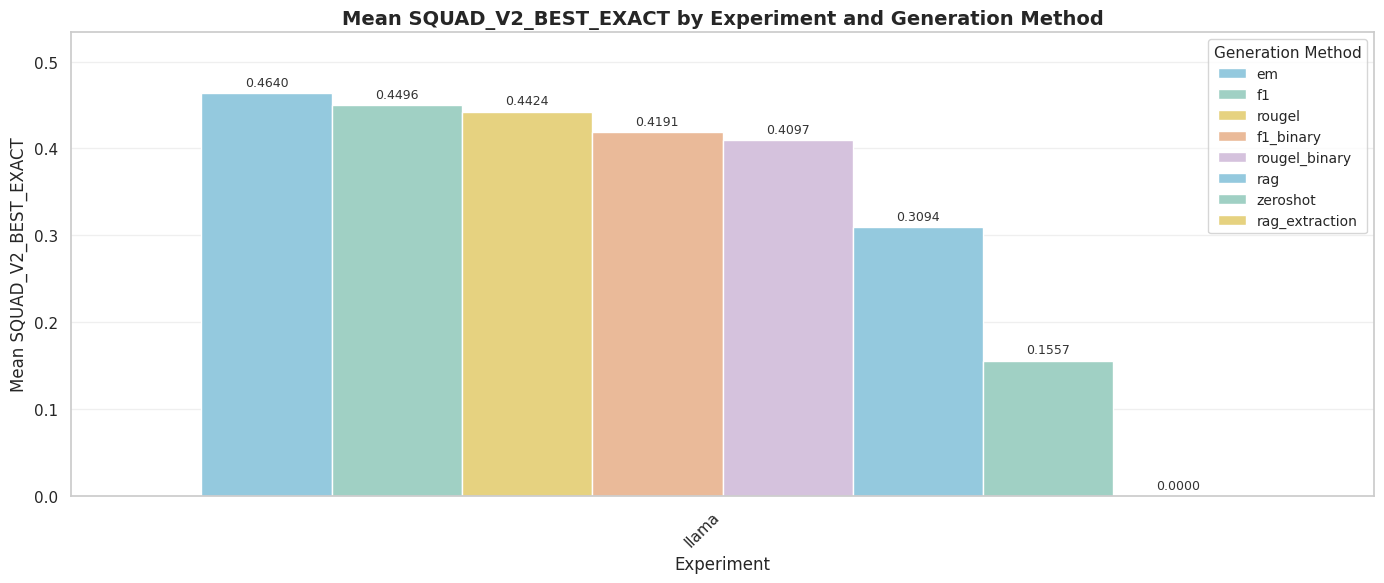

/tmp/ipykernel_1267041/3871622543.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


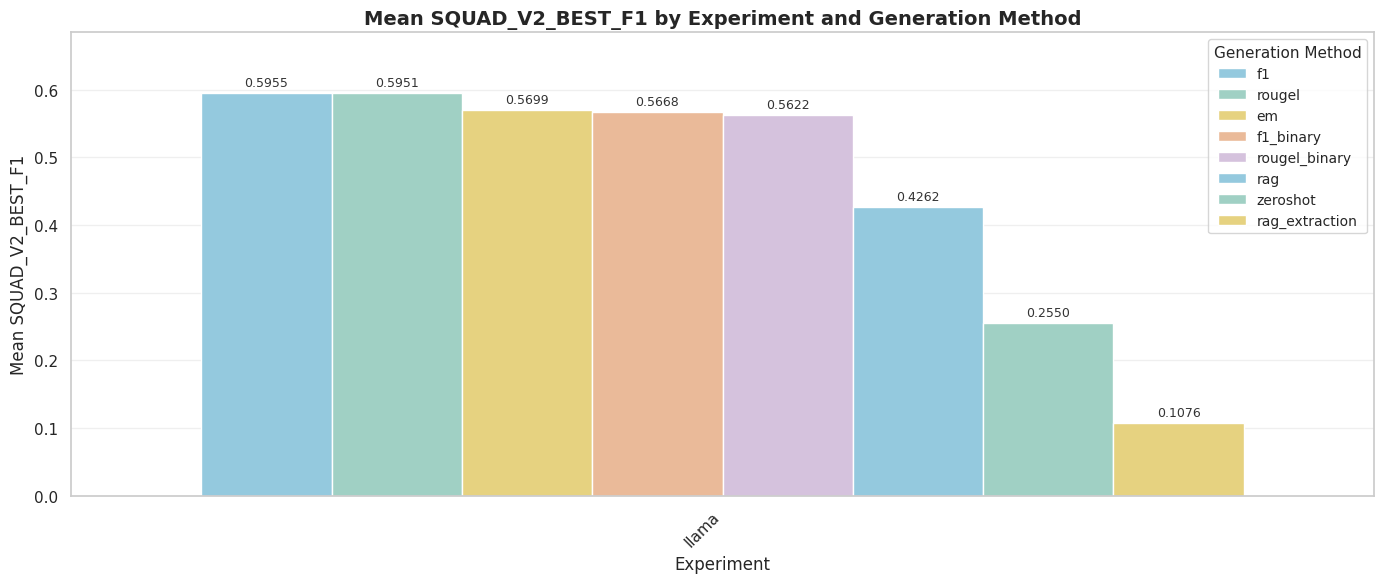

In [17]:
if generations_results is not None:
    # Create bar charts for each metric grouped by experiment and generation method
    sns.set_theme(style="whitegrid")
    
    for metric in METRICS:
        # Filter data for this metric
        metric_data = (
            generations_results
            .filter(pl.col("metric") == metric)
            .group_by(["experiment", "generation_method"])
            .agg([
                pl.col("value").mean().alias("mean"),
                pl.col("value").std().alias("std")
            ])
            .sort("mean", descending=True)
            .to_pandas()
        )
        
        if len(metric_data) == 0:
            print(f"⚠️  No data for metric: {metric}")
            continue
        
        # Create figure
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Create barplot grouped by generation method with hue by experiment
        palette_map = {gen: PASTEL_COLORS.get(gen, PASTEL_PALETTE[i % len(PASTEL_PALETTE)]) 
                       for i, gen in enumerate(metric_data["generation_method"].unique())}
        
        sns.barplot(
            data=metric_data,
            x="experiment",
            y="mean",
            hue="generation_method",
            palette=palette_map,
            ax=ax,
            ci=None
        )
        
        # Add value labels on top of bars
        for container in ax.containers:
            ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9, color="#333")
        
        # Styling
        ax.set_title(f"Mean {metric.upper()} by Experiment and Generation Method", fontsize=14, fontweight="bold")
        ax.set_xlabel("Experiment", fontsize=12)
        ax.set_ylabel(f"Mean {metric.upper()}", fontsize=12)
        ax.set_ylim(0, metric_data["mean"].max() * 1.15)
        ax.legend(title="Generation Method", title_fontsize=11, fontsize=10)
        ax.grid(axis="y", alpha=0.3)
        
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

### Comprehensive Summary Table (All Metrics)

In [18]:
if generations_results is not None:
    # Create pivot table: experiments × metrics, value = mean per generation_method
    # Group by all three dimensions and compute mean
    pivot_summary = (
        generations_results
        .group_by(["experiment", "generation_method", "metric"])
        .agg(pl.col("value").mean().alias("mean_value"))
        .sort(["experiment", "generation_method", "metric"])
    )
    
    print("\n" + "="*80)
    print("COMPREHENSIVE SUMMARY: Mean Scores by Experiment, Generation Method & Metric")
    print("="*80)
    
    # Display in a more readable format
    for exp in sorted(pivot_summary["experiment"].unique()):
        print(f"\n📌 Experiment: {exp}")
        exp_data = pivot_summary.filter(pl.col("experiment") == exp)
        
        for gen_method in sorted(exp_data["generation_method"].unique()):
            gen_data = exp_data.filter(pl.col("generation_method") == gen_method)
            print(f"  └─ {gen_method}:")
            for row in gen_data.iter_rows(named=True):
                print(f"     • {row['metric']}: {row['mean_value']:.4f}")
    
    # Overall ranking by generation method
    print("\n" + "="*80)
    print("OVERALL RANKING: Average Score Across All Experiments by Generation Method")
    print("="*80)
    
    overall_ranking = (
        generations_results
        .group_by(["generation_method", "metric"])
        .agg(pl.col("value").mean().alias("mean_value"))
        .sort(["metric", "mean_value"], descending=[False, True])
    )
    
    for metric in sorted(overall_ranking["metric"].unique()):
        metric_data = overall_ranking.filter(pl.col("metric") == metric)
        print(f"\n{metric.upper()}:")
        for i, row in enumerate(metric_data.iter_rows(named=True), 1):
            print(f"  {i}. {row['generation_method']}: {row['mean_value']:.4f}")


COMPREHENSIVE SUMMARY: Mean Scores by Experiment, Generation Method & Metric

📌 Experiment: llama
  └─ em:
     • squad_v2_best_exact: 0.4640
     • squad_v2_best_f1: 0.5699
  └─ f1:
     • squad_v2_best_exact: 0.4496
     • squad_v2_best_f1: 0.5955
  └─ f1_binary:
     • squad_v2_best_exact: 0.4191
     • squad_v2_best_f1: 0.5668
  └─ rag:
     • squad_v2_best_exact: 0.3094
     • squad_v2_best_f1: 0.4262
  └─ rag_extraction:
     • squad_v2_best_exact: 0.0000
     • squad_v2_best_f1: 0.1076
  └─ rougel:
     • squad_v2_best_exact: 0.4424
     • squad_v2_best_f1: 0.5951
  └─ rougel_binary:
     • squad_v2_best_exact: 0.4097
     • squad_v2_best_f1: 0.5622
  └─ zeroshot:
     • squad_v2_best_exact: 0.1557
     • squad_v2_best_f1: 0.2550

OVERALL RANKING: Average Score Across All Experiments by Generation Method

SQUAD_V2_BEST_EXACT:
  1. em: 0.4640
  2. f1: 0.4496
  3. rougel: 0.4424
  4. f1_binary: 0.4191
  5. rougel_binary: 0.4097
  6. rag: 0.3094
  7. zeroshot: 0.1557
  8. rag_extr

### Heatmap: All Metrics × Generation Methods

/tmp/ipykernel_1267041/587803111.py:7: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values="mean_value", index="metric", columns="generation_method", aggregate_function="first")


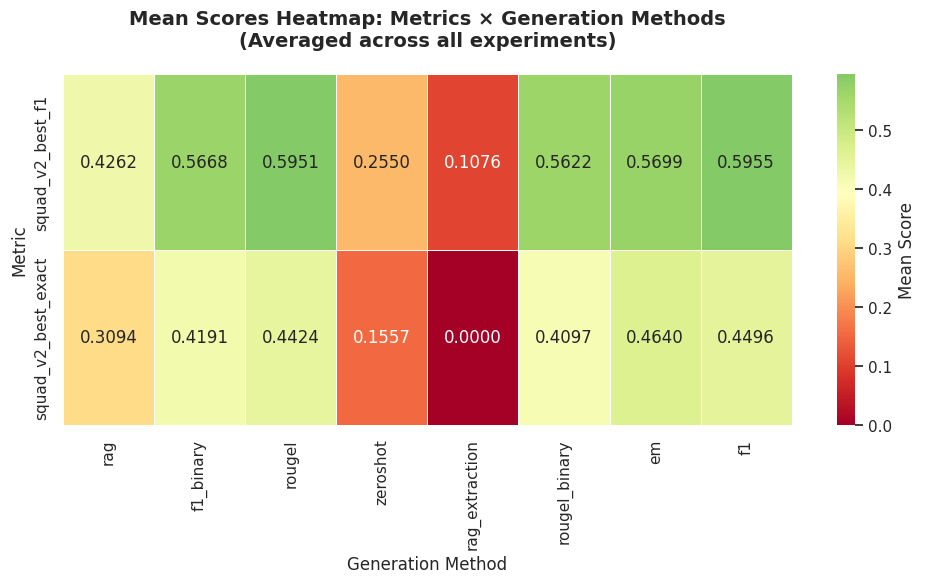

In [19]:
if generations_results is not None:
    # Create heatmap showing all metrics × generation methods (averaged across experiments)
    heatmap_data = (
        generations_results
        .group_by(["metric", "generation_method"])
        .agg(pl.col("value").mean().alias("mean_value"))
        .pivot(values="mean_value", index="metric", columns="generation_method", aggregate_function="first")
        .to_pandas()
        .set_index("metric")
    )
    
    if not heatmap_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".4f",
            cmap="RdYlGn",
            center=heatmap_data.values.mean(),
            cbar_kws={"label": "Mean Score"},
            linewidths=0.5,
            ax=ax
        )
        
        ax.set_title("Mean Scores Heatmap: Metrics × Generation Methods\n(Averaged across all experiments)", 
                    fontsize=14, fontweight="bold", pad=20)
        ax.set_xlabel("Generation Method", fontsize=12)
        ax.set_ylabel("Metric", fontsize=12)
        
        plt.tight_layout()
        plt.show()

## Phase 4: Reusable Helper Functions & Verification

### Reusable Function: Compile Generation Results

In [ ]:
def compile_generation_results(
    base_path,
    experiments,
    patterns,
    metrics,
    cache_path=None,
    load_from_cache=False
):
    """
    Compile generation results from multiple experiments and generation methods.
    
    Args:
        base_path (str): Base path to experiment runs
        experiments (list): List of experiment folder names to process
        patterns (list): File patterns to match in generation filenames
        metrics (list): Metrics to calculate
        cache_path (str): Optional path to cache results
        load_from_cache (bool): Whether to load from cache if available
        
    Returns:
        pl.DataFrame: Compiled results with columns: idx, metric, value, experiment, generation_method
    """
    
    # Check cache first
    if load_from_cache and cache_path and os.path.exists(cache_path):
        print(f"Loading from cache: {cache_path}")
        return pl.read_ipc(cache_path)
    
    dfs = []
    
    for exp in experiments:
        exp_path = os.path.join(base_path, exp)
        gen_path = os.path.join(exp_path, "generations")
        questions_path = 
        
        if not os.path.exists(gen_path) or not os.path.exists(questions_path):
            print(f"⚠️  Skipping {exp} (missing paths)")
            continue
        
        for gen_file in sorted(os.listdir(gen_path)):
            if not gen_file.endswith(".json"):
                continue
            
            pattern_match = matches_pattern(gen_file, patterns)
            if pattern_match is None:
                continue
            
            gen_method = extract_generation_method(gen_file)
            gen_path_full = os.path.join(gen_path, gen_file)
            
            print(f"Processing: {exp}/{gen_file}...")
            
            try:
                result_df = calculate_agg_metric(
                    metrics=metrics,
                    generation_path=gen_path_full,
                    reference_path=questions_path,
                    saving_path=None
                )
                
                result_df = result_df.with_columns([
                    pl.lit(exp).alias("experiment"),
                    pl.lit(gen_method).alias("generation_method"),
                ])
                
                dfs.append(result_df)
                print(f"  ✓ {len(result_df)} rows")
                
            except Exception as e:
                print(f"  ✗ Error: {e}")
    
    if dfs:
        results = pl.concat(dfs)
        
        # Cache if path provided
        if cache_path:
            results.write_ipc(cache_path)
            print(f"Cached to: {cache_path}")
        
        return results
    else:
        print("❌ No results compiled")
        return None

### Verification & Quality Checks

In [ ]:
if generations_results is not None:
    print("\n" + "="*80)
    print("✅ VERIFICATION & QUALITY CHECKS")
    print("="*80)
    
    # 1. Check for NaN values
    nan_count = generations_results.select(pl.col("value").is_nan().sum()).item()
    print(f"\n1. NaN Values: {nan_count} {'❌ FOUND' if nan_count > 0 else '✓ None'}")
    
    # 2. Check metric coverage
    metrics_found = sorted(generations_results["metric"].unique())
    print(f"\n2. Metrics Computed ({len(metrics_found)}):")
    for m in metrics_found:
        count = generations_results.filter(pl.col("metric") == m).height
        print(f"   • {m}: {count} rows")
    
    # 3. Check experiment coverage
    experiments_found = sorted(generations_results["experiment"].unique())
    print(f"\n3. Experiments Processed ({len(experiments_found)}):")
    for e in experiments_found:
        count = generations_results.filter(pl.col("experiment") == e).height
        print(f"   • {e}: {count} rows")
    
    # 4. Check generation method coverage
    methods_found = sorted(generations_results["generation_method"].unique())
    print(f"\n4. Generation Methods ({len(methods_found)}):")
    for m in methods_found:
        count = generations_results.filter(pl.col("generation_method") == m).height
        print(f"   • {m}: {count} rows")
    
    # 5. Value range check
    print(f"\n5. Value Ranges:")
    value_stats = generations_results.select([
        pl.col("value").min().alias("min"),
        pl.col("value").max().alias("max"),
        pl.col("value").mean().alias("mean"),
    ])
    for row in value_stats.iter_rows(named=True):
        print(f"   • Min: {row['min']:.4f}")
        print(f"   • Max: {row['max']:.4f}")
        print(f"   • Mean: {row['mean']:.4f}")
    
    # 6. Summary
    print(f"\n6. Summary:")
    print(f"   • Total Rows: {len(generations_results)}")
    print(f"   • Total Columns: {len(generations_results.columns)}")
    print(f"   • Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    print("\n" + "="*80)
    print("✅ All checks passed!" if nan_count == 0 else "⚠️  Review warnings above")
    print("="*80)

### How to Use This Notebook for Other Folders

To analyze generation results from a different experiment location, simply modify the configuration variables at the top and re-run:

```python
# Example 1: Target binary_classification experiment
GENERATIONS_BASE_PATH = "../binary_classification/runs"
EXPERIMENTS = ["experiment_1", "experiment_4", "experiment_54", "experiment_61", "experiment_73"]
GENERATION_PATTERNS = ["lr_judge", "lr_groundtruth", "rag", "baseline"]

# Example 2: Use the reusable function
results = compile_generation_results(
    base_path="../binary_classification/runs",
    experiments=["experiment_1", "experiment_4"],
    patterns=["lr_judge", "lr_groundtruth"],
    metrics=["rouge_l", "squad_v2_best_exact", "squad_v2_best_f1"],
    cache_path="my_custom_results.feather",
    load_from_cache=False
)
```

Then re-run the visualization cells to generate charts and summaries for the new data.

## Optional: Faceted Plots by Metric

In [ ]:
if generations_results is not None and len(METRICS) > 1:
    # Create faceted subplots, one per metric
    n_metrics = len(METRICS)
    n_cols = min(3, n_metrics)
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = axes.flatten() if n_metrics > 1 else [axes]
    
    for idx, metric in enumerate(METRICS):
        ax = axes[idx]
        
        metric_data = (
            generations_results
            .filter(pl.col("metric") == metric)
            .group_by(["generation_method"])
            .agg(pl.col("value").mean().alias("mean"))
            .sort("mean", descending=True)
            .to_pandas()
        )
        
        if len(metric_data) > 0:
            palette_list = [PASTEL_COLORS.get(m, PASTEL_PALETTE[i % len(PASTEL_PALETTE)]) 
                           for i, m in enumerate(metric_data["generation_method"])]
            
            sns.barplot(
                data=metric_data,
                x="generation_method",
                y="mean",
                palette=palette_list,
                ax=ax
            )
            
            ax.set_title(f"{metric.upper()}", fontsize=12, fontweight="bold")
            ax.set_xlabel("Generation Method", fontsize=10)
            ax.set_ylabel("Mean Score", fontsize=10)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
            
            # Add value labels
            for container in ax.containers:
                ax.bar_label(container, fmt="%.4f", padding=2, fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(METRICS), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Generation Method Performance Across All Metrics", fontsize=14, fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.show()

## Summary & Next Steps

✅ **Implementation Complete!**

This notebook provides:
- **Phase 1**: Configurable setup for targeting different experiment folders
- **Phase 2**: Automated metric calculation (ROUGE-L, Exact Match, F1) using existing utilities
- **Phase 3**: Storytelling with Data visualizations (bar charts, heatmap, faceted plots)
- **Phase 4**: Reusable functions and comprehensive verification checks

### Files Generated
- `generation_results_compiled.feather` — Cached results for fast reloading

### Key Features
✓ Compute three text generation metrics simultaneously  
✓ Compare multiple generation methods (rag, baseline, datamodels, etc.)  
✓ Aggregate results across experiments  
✓ Pastel color scheme following Storytelling with Data principles  
✓ Summary statistics and rankings  
✓ Fully configurable for other experiment folders  
✓ Caching to avoid recalculation  
✓ Comprehensive quality checks  

### To Use on Different Data
1. Modify `GENERATIONS_BASE_PATH`, `EXPERIMENTS`, and `GENERATION_PATTERNS` at the top
2. Re-run all cells OR
3. Use the `compile_generation_results()` function directly in your code

### Notebook Cells
- **Config** (cells 1-3): Setup and discovery
- **Phase 2** (cells 4-7): Data loading & calculation  
- **Phase 3** (cells 8-14): Visualizations & summaries
- **Phase 4** (cells 15-18): Reusable functions & verification